Imports e lettura dei dati

In [372]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [373]:
actors = pd.read_csv('dataSets/mainDataSet/actors.csv')
countries = pd.read_csv('dataSets/mainDataSet/countries.csv')
crew = pd.read_csv('dataSets/mainDataSet/crew.csv')
genres = pd.read_csv('dataSets/mainDataSet/genres.csv')
languages = pd.read_csv('dataSets/mainDataSet/languages.csv')
movies = pd.read_csv('dataSets/mainDataSet/movies.csv')
posters = pd.read_csv('dataSets/mainDataSet/posters.csv') #potrebbe non servire in analisi dati
releases = pd.read_csv('dataSets/mainDataSet/releases.csv') #potrebbe non servire in analisi dati
studios = pd.read_csv('dataSets/mainDataSet/studios.csv')
themes = pd.read_csv('dataSets/mainDataSet/themes.csv') #potrebbe non servire in analisi dati
reviews = pd.read_csv('dataSets/additionalData/rotten_tomatoes_reviews.csv')
oscar=pd.read_csv('dataSets/additionalData/the_oscar_awards.csv')

In [374]:
movies


,id,name,date,tagline,description,minute,rating
0,1000001,Barbie,2023.0,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86
1,1000002,Parasite,2019.0,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56
2,1000003,Everything Everywhere All at Once,2022.0,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30
3,1000004,Fight Club,1999.0,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27
4,1000005,La La Land,2016.0,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09
...,...,...,...,...,...,...,...
941592,1941593,神笛,NaN,NaN,NaN,NaN,NaN
941593,1941594,蟲極道蜜団子抗争編 壱ノ巻,NaN,NaN,Shinjuku forest at night. In the sap taverns o...,30.0,NaN
941594,1941595,蟲極道蜜団子抗争編 弐ノ巻,NaN,NaN,"The city that never sleeps, where insects gath...",30.0,NaN
941595,1941596,重生,NaN,NaN,"In a world where order has broken down, darkne...",NaN,NaN


In [375]:
genres['genre'].value_counts()

genre
Drama              232201
Documentary        163890
Comedy             140636
Animation           58708
Horror              53870
Romance             51549
Thriller            46726
Music               44105
Action              41695
Crime               35507
Family              27511
TV Movie            25874
Adventure           23093
Fantasy             22280
Mystery             21394
Science Fiction     21209
History             17008
War                 10758
Western              8835
Name: count, dtype: int64

In [376]:
genres['genre'].nunique()

19

In [377]:
genres

,id,genre
0,1000001,Comedy
1,1000001,Adventure
2,1000002,Comedy
3,1000002,Thriller
4,1000002,Drama
...,...,...
1046844,1941563,Drama
1046845,1941566,Crime
1046846,1941569,Crime
1046847,1941596,Action


In [378]:
languages

,id,type,language
0,1000001,Language,English
1,1000002,Primary language,Korean
2,1000002,Spoken language,English
3,1000002,Spoken language,German
4,1000002,Spoken language,Korean
...,...,...,...
1038757,1941593,Language,Chinese
1038758,1941594,Language,English
1038759,1941595,Language,English
1038760,1941596,Language,Chinese


capire il dataset

In [379]:
countries.nunique()

id         617192
country       247
dtype: int64

In [380]:
countries['country'].value_counts()

country
USA                                  174489
France                                45725
UK                                    42914
Japan                                 41362
Germany                               41325
                                      ...  
Niue                                      2
Heard Island and McDonald Islands         2
Cocos (Keeling) Islands                   1
Bouvet Island                             1
Norfolk Island                            1
Name: count, Length: 247, dtype: int64

creo un subset di countries di paesi di interesse geopolitico e culturale, di paesi con piu film o paesi di interesse personale


In [381]:
paesi_di_interesse = [
    "USA", "France", "UK", "Japan", "Germany", "India", "Italy",
    "Mexico", "China", "Russian Federation", "South Korea", "USSR",
    "Philippines", "Czechoslovakia", "Poland", "Turkey",
    "Taiwan", "Czechia", "Iran", "Ukraine", "Ireland", "Israel",
    "South Africa", "Malaysia", "New Zealand", "Colombia", "East Germany",
    "Croatia", "Serbia", "Bulgaria", "Slovakia", "Kazakhstan"
]
sub_countries = countries[countries['country'].isin(paesi_di_interesse)]

In [382]:
sub_countries.count()

id         504888
country    504888
dtype: int64

creo un subset di film basato sul subset di countries di interesse

In [383]:
movies

,id,name,date,tagline,description,minute,rating
0,1000001,Barbie,2023.0,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86
1,1000002,Parasite,2019.0,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56
2,1000003,Everything Everywhere All at Once,2022.0,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30
3,1000004,Fight Club,1999.0,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27
4,1000005,La La Land,2016.0,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09
...,...,...,...,...,...,...,...
941592,1941593,神笛,NaN,NaN,NaN,NaN,NaN
941593,1941594,蟲極道蜜団子抗争編 壱ノ巻,NaN,NaN,Shinjuku forest at night. In the sap taverns o...,30.0,NaN
941594,1941595,蟲極道蜜団子抗争編 弐ノ巻,NaN,NaN,"The city that never sleeps, where insects gath...",30.0,NaN
941595,1941596,重生,NaN,NaN,"In a world where order has broken down, darkne...",NaN,NaN


In [384]:
id_filtrati = sub_countries['id'].unique()
df = movies[movies['id'].isin(id_filtrati)].copy()

In [385]:
df.count()

id             472298
name           472297
date           454522
tagline         89355
description    403126
minute         409236
rating          75496
dtype: int64

In [386]:
#creo dataframe, per ogni id di un film crea una lista contenente i paesi che l'hanno prodotto
#countries_aggregated = countries.groupby('id')['country'].apply(list).reset_index()

# Unisce il dataset dei film con i paesi aggregati
#df = pd.merge(movies_filtrati, countries_aggregated, on='id', how='inner')

In [387]:
#df

Merging all Data-sets by id

In [388]:
# Unisci i primi due dataset
#df = pd.merge(movies, countries, on='id', how='inner')

# Unisci il risultato con il terzo dataset
#df = pd.merge(df, ds3, on='id', how='inner')

# Continua fino a unire tutti i dataset
#df = pd.merge(df, ds4, on='id', how='inner')
#df = pd.merge(df, ds5, on='id', how='inner')
#df = pd.merge(df, ds6, on='id', how='inner')
#df = pd.merge(df, ds7, on='id', how='inner')
#df = pd.merge(df, ds8, on='id', how='inner')
#df = pd.merge(df, ds9, on='id', how='inner')
#df.head(1000)

pulizia dei dati

In [389]:
df

,id,name,date,tagline,description,minute,rating
0,1000001,Barbie,2023.0,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86
1,1000002,Parasite,2019.0,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56
2,1000003,Everything Everywhere All at Once,2022.0,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30
3,1000004,Fight Club,1999.0,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27
4,1000005,La La Land,2016.0,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09
...,...,...,...,...,...,...,...
941592,1941593,神笛,NaN,NaN,NaN,NaN,NaN
941593,1941594,蟲極道蜜団子抗争編 壱ノ巻,NaN,NaN,Shinjuku forest at night. In the sap taverns o...,30.0,NaN
941594,1941595,蟲極道蜜団子抗争編 弐ノ巻,NaN,NaN,"The city that never sleeps, where insects gath...",30.0,NaN
941595,1941596,重生,NaN,NaN,"In a world where order has broken down, darkne...",NaN,NaN


In [390]:
df.loc[df.duplicated(subset=['name', 'date', 'minute'])]

,id,name,date,tagline,description,minute,rating
41484,1041485,The Haunted Castle,1897.0,NaN,George Albert Smith's remake of Georges Méliès...,1.0,2.85
42715,1042716,The Darkness,2016.0,NaN,A family lives in a cabin in the middle of a s...,92.0,3.18
65400,1065401,Disclosure,2020.0,"There are two sides to every story, and then t...","Australian documentary maker Emily, and her jo...",107.0,3.44
73818,1073819,Better Than Sex,2000.0,3 days in the life of a 1 night stand.,After a one-night stand a couple is faced with...,84.0,3.24
73819,1073820,Amoklauf,1994.0,NaN,A nameless waiter spends his days sitting arou...,65.0,NaN
...,...,...,...,...,...,...,...
941049,1941050,The Bunker,NaN,We haven't much time...decide!,"On the brink of nuclear destruction, a mother ...",NaN,NaN
941088,1941089,The Daily Life of a Sexist Homosexual,NaN,NaN,This is what happens if you make a mockumentar...,24.0,NaN
941091,1941092,Dead in Love,NaN,It's never too late to come out... or fall in ...,The ghost of a bisexual young woman becomes en...,105.0,NaN
941120,1941121,Don't. Get. Out! 2,NaN,NaN,NaN,NaN,NaN


cancello tutte le righe duplicate

In [391]:
df = df.loc[~df.duplicated(subset=['name', 'date', 'minute'])].reset_index(drop=True).copy() #identifico come duplicati tutti i film con stesso nome data e durata

In [392]:
df.count()

id             470991
name           470990
date           453350
tagline         89200
description    402141
minute         408280
rating          75477
dtype: int64

In [393]:
df.loc[df['name'] == 'untitled']

,id,name,date,tagline,description,minute,rating
143056,1189343,untitled,NaN,NaN,NaN,NaN,NaN
203811,1295520,untitled,1994.0,NaN,NaN,NaN,NaN
204340,1296524,untitled,1996.0,NaN,NaN,NaN,NaN
204345,1296533,untitled,1993.0,NaN,NaN,NaN,NaN
204901,1297545,untitled,1995.0,NaN,NaN,NaN,NaN
205444,1298628,untitled,1992.0,NaN,NaN,NaN,NaN
467449,1933305,untitled,2019.0,NaN,NaN,3.0,NaN


cancello tutte le righe con nome del film "untitled"

In [394]:
maschera_da_eliminare = df['name'] == 'untitled'
df = df.drop(df[maschera_da_eliminare].index).copy()

cambio la colonna date in release_year

In [395]:
df = df.rename(columns={'date': 'release_year'}).copy()
df

,id,name,release_year,tagline,description,minute,rating
0,1000001,Barbie,2023.0,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86
1,1000002,Parasite,2019.0,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56
2,1000003,Everything Everywhere All at Once,2022.0,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30
3,1000004,Fight Club,1999.0,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27
4,1000005,La La Land,2016.0,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09
...,...,...,...,...,...,...,...
470986,1941593,神笛,NaN,NaN,NaN,NaN,NaN
470987,1941594,蟲極道蜜団子抗争編 壱ノ巻,NaN,NaN,Shinjuku forest at night. In the sap taverns o...,30.0,NaN
470988,1941595,蟲極道蜜団子抗争編 弐ノ巻,NaN,NaN,"The city that never sleeps, where insects gath...",30.0,NaN
470989,1941596,重生,NaN,NaN,"In a world where order has broken down, darkne...",NaN,NaN


In [396]:
df.dtypes

id                int64
name             object
release_year    float64
tagline          object
description      object
minute          float64
rating          float64
dtype: object

prime analisi?

In [397]:
df['release_year'].value_counts()

release_year
2023.0    21518
2021.0    18791
2022.0    18762
2019.0    17420
2020.0    17312
          ...  
1882.0        2
1874.0        1
2031.0        1
1885.0        1
1887.0        1
Name: count, Length: 149, dtype: int64

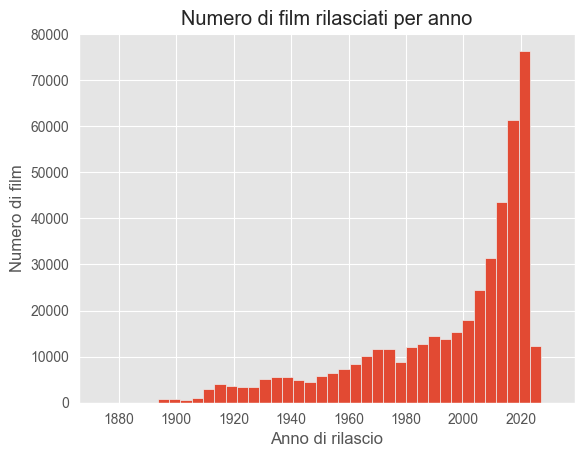

In [398]:
ax = df['release_year'].plot(kind='hist', bins=40, title='Numero di film rilasciati per anno')
ax.set_xlabel('Anno di rilascio')
ax.set_ylabel('Numero di film')
plt.show()

Il numero di film rilasciati annualmente mostra come, con il passare degli anni, la quantità di film e serie tv prodotte sia aumentata in modo quasi esponenziale. Questo fenomeno è dovuto sopratuttutto all'avanzamento tecnologico che ha reso la produzione cinematografica meno costosa e più accessibile; in piu la creazione di piattaforme di distribuzione digitale, come Netflix, YouTube e Amazon Prime, hanno ridotto i costi di distribuzione e reso più semplice fruire dei film, aumentando anche la domanda di nuovi contenuti.

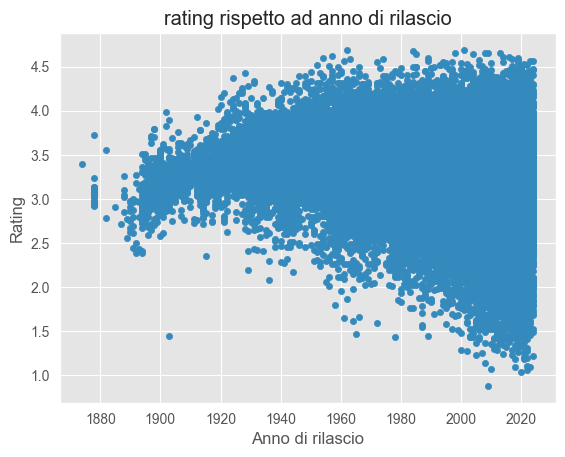

In [399]:
ax = df.plot(kind='scatter', x='release_year', y='rating', title='rating rispetto ad anno di rilascio')
ax.set_xlabel('Anno di rilascio')
ax.set_ylabel('Rating')
plt.show()

Nel corso degli anni, la qualità dei film, misurata attraverso i rating, è aumentata costantemente dal 1890 fino al 1925. Tuttavia, a partire da quel periodo, l'aumento esponenziale del numero di film prodotti ha portato a una divergenza significativa nei rating: da un lato, il rating massimo è continuato a crescere, raggiungendo picchi di eccellenza, mentre dall'altro, il rating minimo è diminuito drasticamente, riflettendo una maggiore variabilità nella qualità delle produzioni.

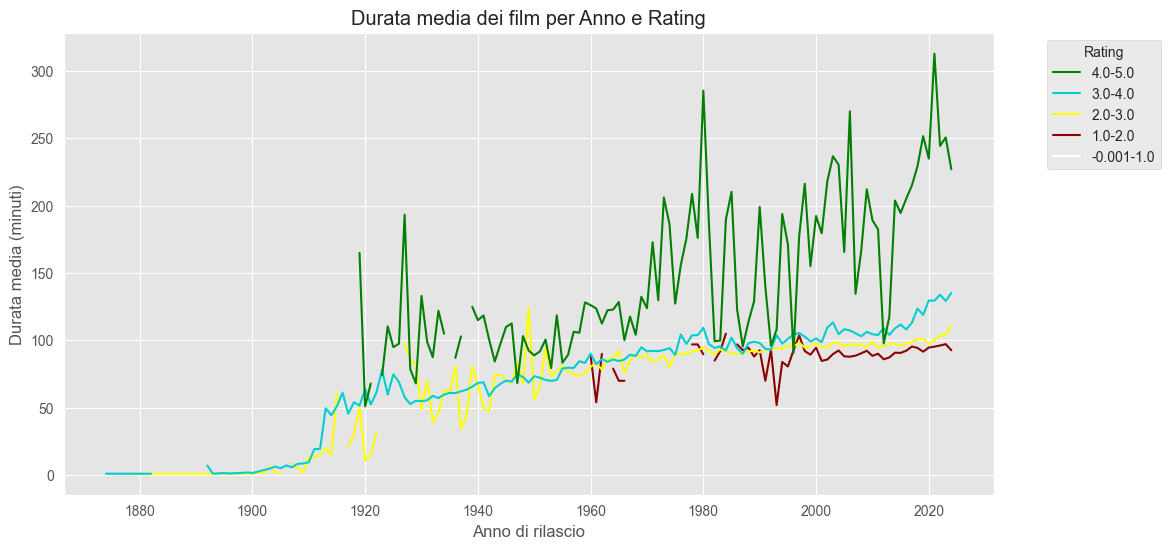

In [400]:
# Crea gli intervalli di 1,0 da 0 a 5
bins = np.arange(0, 6, 1)  # Crea intervalli da 0 a 5 con passo di 1

# Raggruppa i rating in questi intervalli
df['rating_group'] = pd.cut(df['rating'], bins=bins, include_lowest=True)

# Definisci la palette personalizzata usando oggetti Interval
custom_palette = {
    pd.Interval(-0.001, 1.0, closed='right'): '#FFFFFF',  # Bianco per 0-1
    pd.Interval(1.0, 2.0, closed='right'): '#8B0000',     # Rosso scuro per 1-2
    pd.Interval(2.0, 3.0, closed='right'): '#FFFF00',     # Giallo per 2-3
    pd.Interval(3.0, 4.0, closed='right'): '#00CED1',     # Celeste per 3-4
    pd.Interval(4.0, 5.0, closed='right'): '#008000'      # Verde per 4-5
}

# Inverti l'ordine delle categorie di rating_group
df['rating_group'] = df['rating_group'].cat.reorder_categories(
    df['rating_group'].cat.categories[::-1], ordered=True
)

# Calcola la durata media per anno e rating
df_avg = df.groupby(['release_year', 'rating_group'], observed=True)['minute'].mean().unstack()

# Crea il grafico a linee
plt.figure(figsize=(12, 6))
for interval, color in custom_palette.items():
    if interval in df_avg.columns:
        plt.plot(df_avg.index, df_avg[interval], label=f'{interval.left}-{interval.right}', color=color)

# Inverti l'ordine degli elementi nella legenda
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('Anno di rilascio')
plt.ylabel('Durata media (minuti)')
plt.title('Durata media dei film per Anno e Rating')
plt.show()

La durata media delle pellicole prodotte è aumentata in modo significativo nel corso degli anni. Questo fenomeno è attribuibile alla crescente produzione di serie TV e anime. Inoltre, è interessante notare che le pellicole con una durata media più lunga tendono a essere quelle più apprezzate, come dimostrato dai rating più elevati che spesso ricevono.

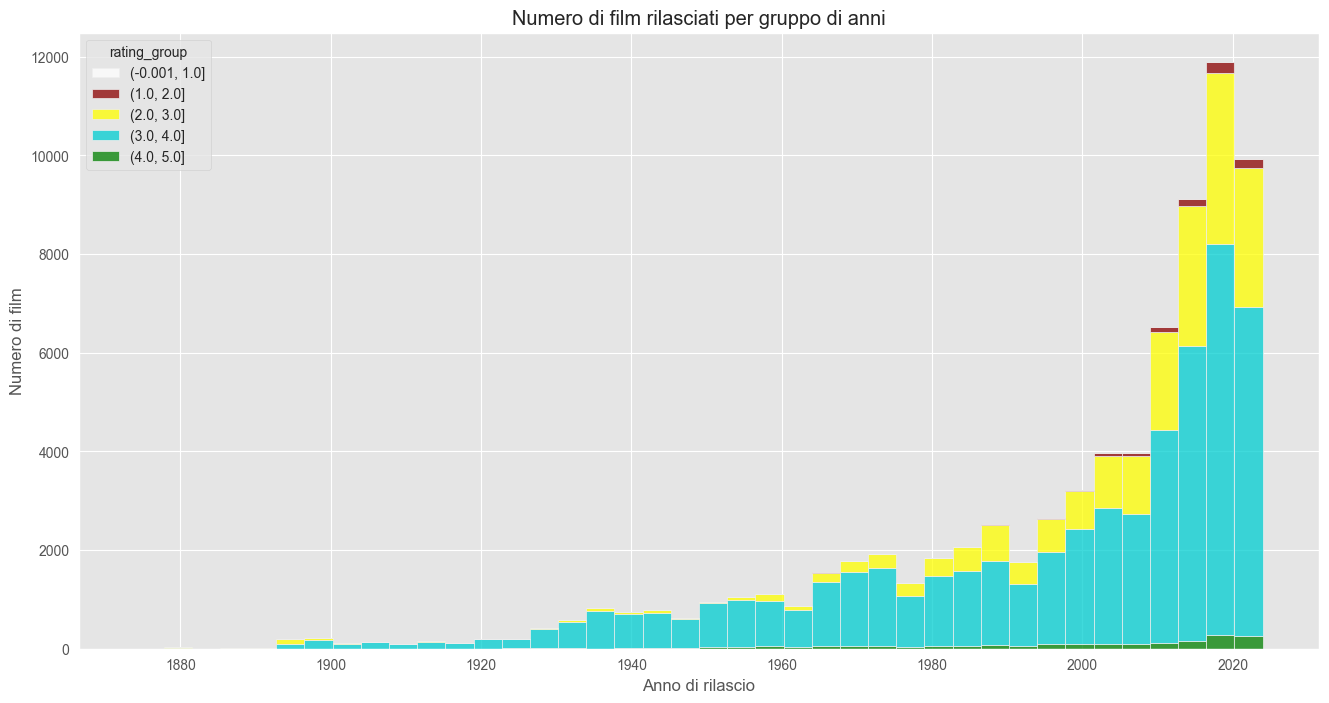

In [401]:
# Trova l'anno minimo e massimo
anno_min = int(df['release_year'].min())
anno_max = int(df['release_year'].max())

# Crea gli intervalli di anni (ogni 4 anni)
bins_anni = np.arange(anno_min, anno_max + 4, 4)  # Intervalli di 4 anni

# Raggruppa gli anni in questi intervalli
df['year_group'] = pd.cut(df['release_year'], bins=bins_anni, include_lowest=True)

# Converti 'rating_group' in una variabile categorica e inverti l'ordine delle categorie
df['rating_group'] = df['rating_group'].astype('category')
df['rating_group'] = df['rating_group'].cat.reorder_categories(
    df['rating_group'].cat.categories[::-1], ordered=True
)

# Crea un grafico a barre sovrapposte
plt.figure(figsize=(16, 8))
ax = sns.histplot(data=df, x='release_year', hue='rating_group', bins=len(bins_anni) - 1, multiple='stack', palette=custom_palette)

# Aggiungi la legenda
handles, labels = ax.get_legend_handles_labels()
if handles:  # Verifica se ci sono elementi nella legenda
    plt.legend(handles, labels, title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Numero di film rilasciati per gruppo di anni')
plt.xlabel('Anno di rilascio')
plt.ylabel('Numero di film')
plt.show()

In [402]:
df.loc[df['release_year']==2000]

,id,name,release_year,tagline,description,minute,rating,rating_group,year_group
25,1000026,American Psycho,2000.0,I think my mask of sanity is about to slip.,A wealthy New York investment banking executiv...,102.0,3.86,"(3.0, 4.0]","(1998.0, 2002.0]"
117,1000118,Memento,2000.0,Some memories are best forgotten.,Leonard Shelby is tracking down the man who ra...,113.0,4.17,"(4.0, 5.0]","(1998.0, 2002.0]"
146,1000147,Requiem for a Dream,2000.0,NaN,The hopes and dreams of four ambitious people ...,102.0,4.10,"(4.0, 5.0]","(1998.0, 2002.0]"
274,1000275,In the Mood for Love,2000.0,"Feel the heat, keep the feeling burning, let t...","Taking place in Hong Kong of 1962, a melanchol...",98.0,4.40,"(4.0, 5.0]","(1998.0, 2002.0]"
292,1000293,Gladiator,2000.0,A Hero Will Rise.,"In the year 180, the death of emperor Marcus A...",155.0,4.11,"(4.0, 5.0]","(1998.0, 2002.0]"
...,...,...,...,...,...,...,...,...,...
468873,1936706,Vánoce s Hutkou,2000.0,NaN,NaN,20.0,NaN,NaN,"(1998.0, 2002.0]"
468874,1936707,Zap!,2000.0,NaN,NaN,5.0,NaN,NaN,"(1998.0, 2002.0]"
470330,1940742,"Un enfant, un secret",2000.0,NaN,NaN,90.0,NaN,NaN,"(1998.0, 2002.0]"
470331,1940744,"Amálka, ja sa zbláznim!",2000.0,NaN,NaN,61.0,NaN,NaN,"(1998.0, 2002.0]"


In [403]:
genres['genre'].unique()

array(['Comedy', 'Adventure', 'Thriller', 'Drama', 'Science Fiction',
       'Action', 'Music', 'Romance', 'History', 'Crime', 'Animation',
       'Mystery', 'Horror', 'Family', 'Fantasy', 'War', 'Western',
       'TV Movie', 'Documentary'], dtype=object)